In [16]:
#necessary module
import os ; import sys
sys.path.append(os.getcwd()+"/Equantum")
#path to data
datapath="/Users/yzaho/Projects/EQuantumAI/Datas/dotgate_center"
setuppath="/Users/yzaho/Projects/EQuantumAI/Datas/dotgate_center/setup/"
from sites import Site
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from fsc import FSC
import scipy.linalg as sl
import scipy.constants as sc
import importlib
import poissonsolver as psolver
#import kwant
import scipy.io as sio

%matplotlib widget

from EQsystem import System

In [17]:
import fsc
importlib.reload(fsc)
from fsc import FSC

import EQsystem
importlib.reload(EQsystem)
from EQsystem import System
#test module


from scipy.interpolate import interp1d
from scipy.optimize import brentq

import poissonsolver
importlib.reload(poissonsolver)

<module 'poissonsolver' from '/Users/yzaho/Projects/EQuantumAI/EQuantum/Equantum/poissonsolver.py'>

In [18]:
import qbuilder
importlib.reload(qbuilder)
import poissonsolver
importlib.reload(poissonsolver)
import poissonsolver as psolver

In [19]:
import solvers
importlib.reload(solvers)
from solvers import local_solver

## Define system

In [5]:
def density_function(z):
        spacing0 = 0.015 # spacing at r=0
        k = 0.  # spacing increases by 0.05 per unit distance
        return spacing0 + k * z

In [20]:
def density_function(z):
        spacing0 = 0.02 # spacing at r=0
        k = 0.2  # spacing increases by 0.05 per unit distance
        if abs(z)<3*spacing0:
            return spacing0   #define same lattice for the layers above/beneath quantum system, avoid oscillation due to the lattice mismatch
        else:
            return spacing0 + k * z

In [21]:
geoparams={"lattice_type": "square",   # or honeycomb_lattice, etc.
"box_size": ((-0.6, 0.6), (-0.6, 0.6), (-0.08, 0.08)),
"sampling_density_function": density_function,
"quantum_center": (0,0,0)     # optional, defaults to (0,0,0)
              }

## Initialize System

In [22]:
import os
import hashlib
import inspect

def get_geoparams_hash(params, *funcs):
    params_repr = {}
    for k, v in params.items():
        if callable(v):
            try:
                params_repr[k] = inspect.getsource(v).strip()
            except Exception:
                params_repr[k] = str(v)
        else:
            params_repr[k] = str(v)
            
    for f in funcs:
        try:
            params_repr[f.__name__] = inspect.getsource(f).strip()
        except Exception:
            pass
            
    # Sort keys for consistent hashing
    params_str = str(sorted(params_repr.items()))
    return hashlib.md5(params_str.encode()).hexdigest(), params_repr

current_hash, params_repr = get_geoparams_hash(geoparams, density_function)

hash_folder = os.path.join(setuppath, f"setup_{current_hash}")
hash_file = os.path.join(hash_folder, "geoparams_hash.txt")
sites_file = os.path.join(hash_folder, "sites.json")
readme_file = os.path.join(hash_folder, "README.txt")


generate_sites = True
if os.path.exists(hash_folder) and os.path.exists(sites_file) and os.path.exists(hash_file):
    with open(hash_file, "r") as f:
        saved_hash = f.read().strip()
    if saved_hash == current_hash:
        generate_sites = False
        print(f"Settings unchanged. Found existing setup in {hash_folder}. Skipping generation.")

if generate_sites:
    print(f"Generating new setup in {hash_folder}...")
    os.makedirs(hash_folder, exist_ok=True)
    syst=System(geoparams,assign_mat=False)
    syst.export_sites(filename=sites_file)
    with open(hash_file, "w") as f:
        f.write(current_hash)
    with open(readme_file, "w") as f:
        f.write("Parameter settings for this setup:")
        for k, v in params_repr.items():
            f.write(f"{k}:{v}")

Generating new setup in /Users/yzaho/Projects/EQuantumAI/Datas/dotgate_center/setup/setup_713e38222f7c9072e4e897af296c99c0...
Generated 22044 points in 3D.
Vacuum pruning: removed 0 sites
EQsystem is successfully initialized.


## Initialized Setup

In [23]:
setuppathupdate=hash_folder
config_file=setuppathupdate+"/updated_sites_dot.json"
syst=System(geoparams,config_file=config_file,ifqsystem=True,quantum_builder="default")

Generated 22044 points in 3D.
Voronoi cells have been created.
5 sites have been removed from the system.
Vacuum pruning: removed 9388 sites
The quantum system has been built using the default solver.
Quantum system is generated using default.
EQsystem is successfully initialized.


/Users/yzaho/Projects/EQuantumAI/EQuantum/Equantum/EQsystem.py:418: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  Export the sites from the System as a JSON file.


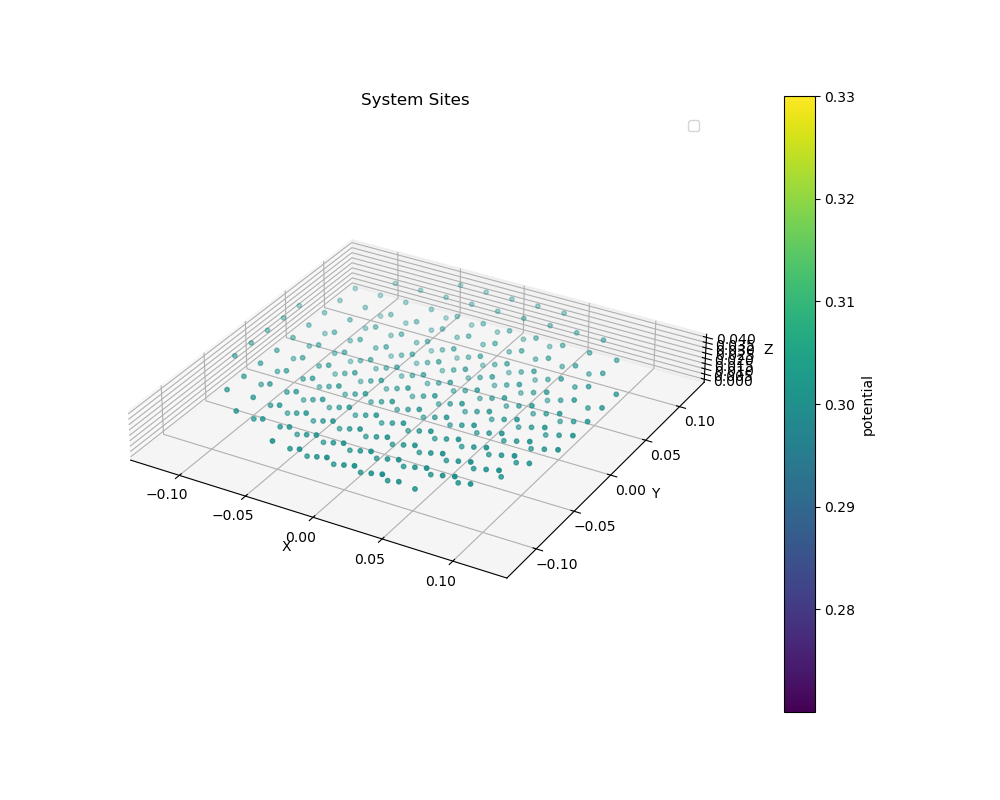

(<Figure size 1000x800 with 2 Axes>,
 <Axes3D: title={'center': 'System Sites'}, xlabel='X', ylabel='Y', zlabel='Z'>)

In [24]:
syst.plot_geometry(material='gate',prop='potential')

## Initialize Quantum problem

In [25]:
qparams={'Ufunc': lambda x:0,'phi':0.0884}
fsc=FSC(syst,ifinitial=False,qparams=qparams,approx="TF")

🔄 Full Hamiltonian rebuild (qparams change)
site_map: 0.00016337493434548378
update_U: 0.0044221660355106
LDOS is calculated through kpm as a whole system.
update_ildos: 0.08015091600827873
alloc+fill: 0.0038200829876586795
copy back: 0.005287333042360842


In [30]:
boundary_condition={
    'gate': {'potential': -1},
    'dielectric': {'dielectric_constant': 4},
    'backgate': {'potential': 0.2}}
fsc.update_BC(updates=boundary_condition,ifinitial=True)

The poisson problem has been initialized.


## Check the Spectrum

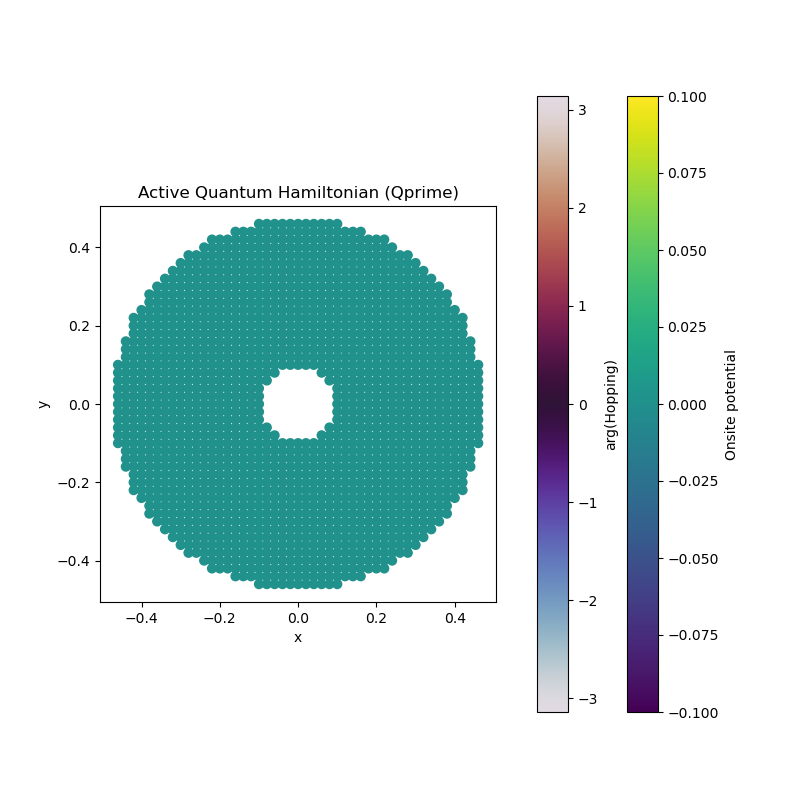

1696


In [27]:
fsc.plot_Hamiltonian()
print(len(fsc.Qsites))

-0.0033474241065576207
0.0013013380279280793


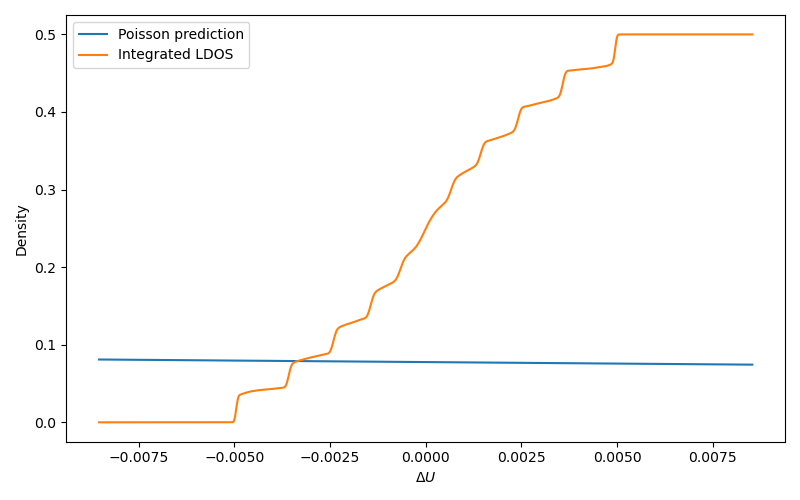

In [31]:
qidx = 1554  # index in Qprime

site_id = fsc.Qprime[qidx]
sidx = np.where(np.array(fsc.Qsites) == site_id)[0][0]

ni = fsc.ni[site_id]
Ci = fsc.Ci[qidx]
ildos = fsc.ildos[sidx]
Ui = fsc.Ui[site_id]

x_dis = np.asarray(ildos[0], dtype=float) - Ui
y_dis = np.asarray(ildos[1], dtype=float)

# cumulative integral using trapezoidal rule
ildos_dis = np.zeros_like(y_dis, dtype=float)
ildos_dis[1:] = np.cumsum(0.5 * (y_dis[1:] + y_dis[:-1]) * np.diff(x_dis))

ildos_interp = interp1d(
    x_dis,
    ildos_dis,
    kind='linear',
    fill_value='extrapolate',
    bounds_error=False
)

def dn_for_Ci(dU):
    return dU * Ci + ni

def diff(dU):
    return np.abs(dn_for_Ci(dU) - ildos_interp(dU))
def F(dU):
    return ni + Ci * dU - ildos_interp(dU)


limits = (float(np.min(x_dis)), float(np.max(x_dis)))

a, b = limits

try:
    Fa, Fb = F(a), F(b)
    if np.isfinite(Fa) and np.isfinite(Fb) and Fa * Fb <= 0:
        dUsol = brentq(F, a, b)
    else:
        res = minimize_scalar(lambda u: abs(F(u)), bounds=limits, method="bounded")
        dUsol = res.x
except Exception:
    res = minimize_scalar(lambda u: abs(F(u)), bounds=limits, method="bounded")
    dUsol = res.x

print(dUsol)
print(Ci*dUsol)
plt.figure(figsize=(8, 5))
plt.plot(x_dis, [dn_for_Ci(dU) for dU in x_dis], label="Poisson prediction")
plt.plot(x_dis, ildos_dis, label="Integrated LDOS")
#plt.plot(x_dis, [diff(dU) for dU in x_dis], label="Mismatch")
plt.xlabel(r"$\Delta U$")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## Solve FSC

In [19]:
fsc.Ncore=20
fsc.convergence_tol=[1e-3,1e-2]
fsc.solve(
    syst,
    save=True,
    snapshot_mode="step",
    snapshot_every=1,
    snapshot_folder=setuppathupdate+"/fsc_logs_ED_e_4_alpha_0.4",
    save_ildos=True,
    ldos_method="ED",
    eta=0.00015,
    #M=256,
    #eps=0.05,
    #kernel="jackson",
)

Iteration counts [Step I, Step II, Step III]: [0, 0, 0]
Solver streak: None, 0

--- Iteration 0 ---
Qprime size   : 5645
max |Δn|      : 3.485e-04
|Δn| per site  : 5.869e-05
|Δn| per site % : 1.376e-04
max |ΔILDOS|  : 1.541e+03
|ΔILDOS| per site  : 8.461e+01
|ΔILDOS| per site % : 6.190e+10
last Poisson  : 7.383 s
last Quantum  : 38.833 s
0.13786465576899207 0.06558788373003009
Iteration counts [Step I, Step II, Step III]: [0, 1, 0]
Solver streak: poisson, 1

--- Iteration 1 ---
Qprime size   : 5645
max |Δn|      : 1.131e-01
|Δn| per site  : 4.139e-03
|Δn| per site % : 1.191e-03
max |ΔILDOS|  : 1.541e+03
|ΔILDOS| per site  : 8.461e+01
|ΔILDOS| per site % : 6.190e+10
last Poisson  : 7.278 s
last Quantum  : 38.833 s
0.07918519421849102 0.037813084712847646
Iteration counts [Step I, Step II, Step III]: [0, 2, 0]
Solver streak: poisson, 2

--- Iteration 2 ---
Qprime size   : 5645
max |Δn|      : 6.941e-02
|Δn| per site  : 2.388e-03
|Δn| per site % : 6.507e-04
max |ΔILDOS|  : 1.541e+03
|ΔILD